# RNN - Modelo Aplicado a demanda energética Alemania

# Cambiar por los datos a nivel semanal

Se desarrolla una RNN para predecir la demanda de consumo. Los datos provienen de SMARD - base de datos que contiene información relacionada al consumo de energía en Alemania.
organizar como estaba, primero todas las vbles, luego se parte en folds/val. Preguntar que pasa en el caso en el que se generan rangos de predicicones distintos

Fuente: https://www.smard.de/en/downloadcenter/download-market-data/?downloadAttributes=%7B"selectedCategory":2,"selectedSubCategory":5,"selectedRegion":"DE","selectedFileType":"CSV","from":1420066800000,"to":1767221999999%7D)''

In [1]:
# Machine Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models,optimizers, callbacks
from tensorflow.keras.layers import Dropout

# configuración del entorno
import json
import os
import warnings
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
warnings.filterwarnings("ignore")

# modelado
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error
)

from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError

# visual
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import plotly.graph_objects as go
#plt.style.use("seaborn-v0_8-darkgrid")
#sns.set_palette("viridis")

# optimizacion
import optuna
import optuna.visualization as vis
from optuna.samplers import TPESampler

np.random.seed(42)
tf.random.set_seed(42)

Se cargan los datos (inicialmente los datos estaban dados en días, lo que se hizo fue tomar la media semanal de las observaciones, dado que se tomaron 10 años de datos. Este proceso ya fue realizado antes de cargar los datos. La fecha mostrada es el lunes de cada semana). El orden de las observaciones está dado en millones

In [2]:
data_demand =  pd.read_csv("../../../data/csv/EC_GER_Weekly.csv")
df_data_demand = pd.DataFrame(data_demand.copy()) # copia del df de precios de cierre como df
df_data_demand["Start date"] = pd.to_datetime(df_data_demand["Start date"]) # conversión a formato fecha
df_data_close = df_data_demand.sort_values(by="Start date", ascending=True) # se ordena por fecha ascendente
df_data_close.head()


,Start date,value
0,2015-01-05,1.240580e+06
1,2015-01-12,1.465239e+06
2,2015-01-19,1.479857e+06
3,2015-01-26,1.516270e+06
4,2015-02-02,1.507588e+06


Se grafican los datos 

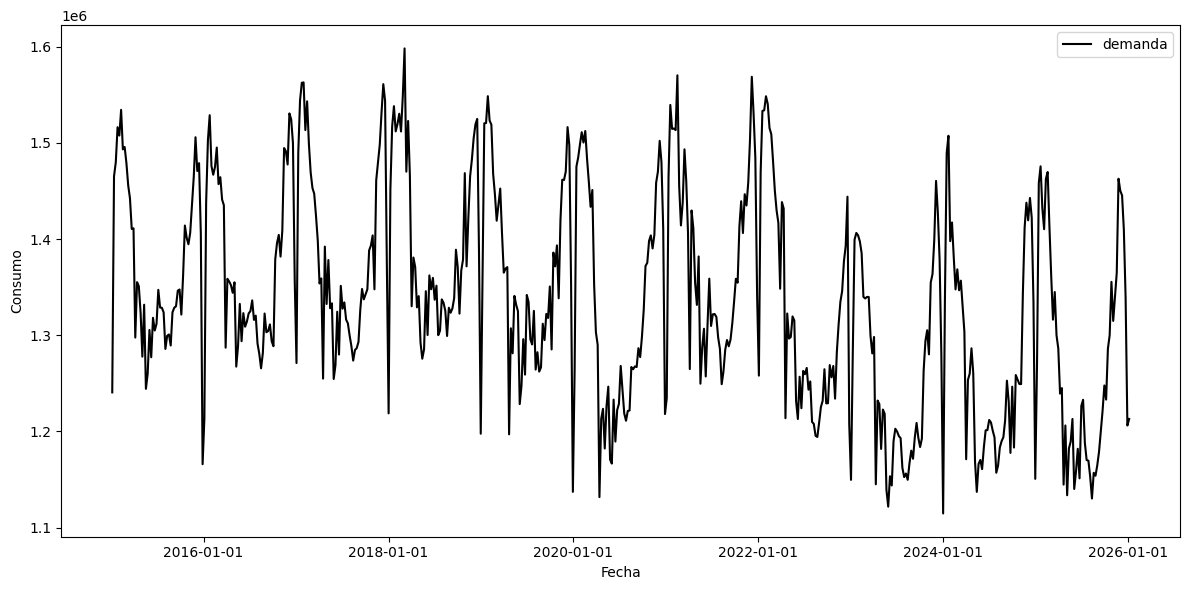

In [3]:
# # se grafican los datos de consumo de forma semanal
plt.figure(figsize=(12,6))
plt.plot(df_data_close["Start date"], df_data_close["value"], label="demanda", color="black")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
#plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

Ahora se definen las funciones y variables adicionales derivadas de la serie: 
En esta parte se determinan variables temporales (año, mes trimestre)

In [4]:
# se definen variables generales a tener en cuenta en el df a partir de la fecha: temporalidades: año, mes, día, día de la semana, cuatrimestre
def get_data_times(df, columnName):
    df_copy = df.copy()
    df_copy["year"] = df_copy[columnName].apply(lambda x: x.year)
    df_copy["month"] = df_copy[columnName].apply(lambda x: x.month)
    #df_copy["day"] = df_copy[columnName].apply(lambda x: x.day)
    #df_copy["dayofweek"] = df_copy[columnName].apply(lambda x: x.dayofweek)
    df_copy["quarter"] = df_copy[columnName].apply(lambda x: x.quarter)
    return df_copy

df_data_close_copy = get_data_times(df_data_close, columnName="Start date")
df_data_close_copy.head()

,Start date,value,year,month,quarter
0,2015-01-05,1.240580e+06,2015,1,1
1,2015-01-12,1.465239e+06,2015,1,1
2,2015-01-19,1.479857e+06,2015,1,1
3,2015-01-26,1.516270e+06,2015,1,1
4,2015-02-02,1.507588e+06,2015,2,1


valor semana actual año anterior

In [5]:

#df_data_close_copy["value_lag_1y"] = df_data_close_copy["value"].shift(52)
# 52 valores atras (el valor de la semana que se quiere ver un año atras)
df_data_close_copy = df_data_close_copy.dropna()

se toman los rezagos respecto al valor inicial: lags = [1, 2, 3, 4, 8, 12, 52] (recordar que los valores son dados por semana, no por día)

In [6]:
# por eso se toma el valor rezagado de la serie
# función que recibe como argumentos un array con los nombres de las columnas y un array con los rezagos a calcular

def make_df_full_lags(df, lags, variables):
    df_copy = df.copy()
    for variable in variables:
        for lag in lags:
            df_copy[f"{variable}_lag_{str(lag)}"] = df_copy[f"{variable}"].shift(lag)

    return df_copy

variables = [col for col in df_data_close.columns if ("value" in col ) ]
# rezagos por días
# lags = [1,2,7,15,30,60,90]

# rezagos por semanas
lags = [1, 2, 3, 4, 8, 12, 52]
df_data_close_copy = make_df_full_lags(df_data_close_copy, lags, variables).dropna()
df_data_close_copy = df_data_close_copy.reset_index(drop=True)
df_data_close_copy.head()
#df_data_close[["value", "value_lag_1", "value_lag_2"]]

,Start date,value,year,month,quarter,value_lag_1,value_lag_2,value_lag_3,value_lag_4,value_lag_8,value_lag_12,value_lag_52
0,2016-01-04,1.213233e+06,2016,1,1,1.165943e+06,1.404996e+06,1.478872e+06,1.470758e+06,1.406408e+06,1.362325e+06,1.240580e+06
1,2016-01-11,1.437911e+06,2016,1,1,1.213233e+06,1.165943e+06,1.404996e+06,1.478872e+06,1.435765e+06,1.414048e+06,1.465239e+06
2,2016-01-18,1.502718e+06,2016,1,1,1.437911e+06,1.213233e+06,1.165943e+06,1.404996e+06,1.464466e+06,1.401533e+06,1.479857e+06
3,2016-01-25,1.528752e+06,2016,1,1,1.502718e+06,1.437911e+06,1.213233e+06,1.165943e+06,1.505831e+06,1.394589e+06,1.516270e+06
4,2016-02-01,1.475937e+06,2016,2,1,1.528752e+06,1.502718e+06,1.437911e+06,1.213233e+06,1.470758e+06,1.406408e+06,1.507588e+06


In [7]:
len(df_data_close_copy)

523

Cálculo de medias móviles para diversos periodos, que funcionan como variables de entrada adicionales

In [8]:
# medias móviles de los precios de cierre: se crea una función para que tome las medias móviles de 
# 7,15,30,60,90 días. Se toman estas medias moviles para los precios anteriores
def make_df_full_averages(df, vars_list, ma_periods, dropna=True, overwrite=False):
    df_copy = df.copy()

    # solo permitir variables originales (sin _lag_ ni _ma_)
    clean_vars = [
        v for v in vars_list
        if v in df_copy.columns and "_lag_" not in v and "_ma_" not in v
    ]

    missing = [v for v in vars_list if v not in df_copy.columns]
    if missing:
        raise ValueError(f"Estas columnas no existen: {missing}")

    for variable in clean_vars:
        for period in ma_periods:
            name = f"{variable}_ma_{period}"

            if (name in df_copy.columns) and (not overwrite):
                continue

            df_copy[name] = (
                df_copy[variable]
                .shift(1)  # evita leakage, dado que se toma desde la posición t-1 hacia atras
                .rolling(window=period)
                .mean()
            )

    if dropna:
        df_copy = df_copy.reset_index(drop=True).dropna()

    return df_copy

# periodos para ma por días
# ma_periods = [7, 15, 30, 60, 90]

# periodos ma por semanas
ma_periods = [
    2, # dos semanas desde la anterior
    3, # tres semanas desde la anterior
    4, # 4 semanas desde la anterior (desde la ultima semana, un mes)
    8, # 8 semanas desde la anterior (desde la ultima semana, dos meses)
    12, # 12 semanas desde la anterior (desde la ultima semana, tres meses)
    16 # 16 semanas desde la anterior (desde la última semana, 4 meses)
]

df_data_close_copy = make_df_full_averages(
    df_data_close_copy,
    vars_list=variables,
    ma_periods=ma_periods
)

df_data_close_copy.head()

,Start date,value,year,month,quarter,value_lag_1,value_lag_2,value_lag_3,value_lag_4,value_lag_8,value_lag_12,value_lag_52,value_ma_2,value_ma_3,value_ma_4,value_ma_8,value_ma_12,value_ma_16
16,2016-04-25,1.344112e+06,2016,4,2,1.352060e+06,1.355867e+06,1.358682e+06,1.287062e+06,1.457129e+06,1.475937e+06,1.323606e+06,1.353963e+06,1.355536e+06,1.338418e+06,1.393927e+06,1.422028e+06,1.421685e+06
17,2016-05-02,1.354987e+06,2016,5,2,1.344112e+06,1.352060e+06,1.355867e+06,1.358682e+06,1.464299e+06,1.466870e+06,1.277736e+06,1.348086e+06,1.350679e+06,1.352680e+06,1.379800e+06,1.411043e+06,1.429865e+06
18,2016-05-09,1.267394e+06,2016,5,2,1.354987e+06,1.344112e+06,1.352060e+06,1.355867e+06,1.441140e+06,1.475012e+06,1.331730e+06,1.349550e+06,1.350386e+06,1.351756e+06,1.366136e+06,1.401719e+06,1.424682e+06
19,2016-05-16,1.288666e+06,2016,5,2,1.267394e+06,1.354987e+06,1.344112e+06,1.352060e+06,1.435180e+06,1.495105e+06,1.244288e+06,1.311191e+06,1.322164e+06,1.329638e+06,1.344418e+06,1.384418e+06,1.409974e+06
20,2016-05-23,1.332559e+06,2016,5,2,1.288666e+06,1.267394e+06,1.354987e+06,1.344112e+06,1.287062e+06,1.457129e+06,1.259924e+06,1.278030e+06,1.303682e+06,1.313790e+06,1.326104e+06,1.367215e+06,1.394969e+06


In [9]:
len(df_data_close_copy)

507

Se seleccionan las variables que serán las variables de entrada del modelo

In [37]:
# selecicon de variables (tener en cuenta que los lags se calculan a partir del ultimo rezago)
target = ["value"]
features = [col for col in df_data_close_copy.columns if 
            (col not in target and col != "Start date")]
features

['year',
 'month',
 'quarter',
 'value_lag_1',
 'value_lag_2',
 'value_lag_3',
 'value_lag_4',
 'value_lag_8',
 'value_lag_12',
 'value_lag_52',
 'value_ma_2',
 'value_ma_3',
 'value_ma_4',
 'value_ma_8',
 'value_ma_12',
 'value_ma_16']

Ahora se crea la función que creará las ventanas con los rezagos para ingresar en la red. Para que la RNN reciba los datos como un tensor de orden 3, la función crea un dataset para los datos de entrenamiento de la RNN.

In [11]:
# create_dataset es una función que genera los datos de entrada X y los datos de salida y
# se crea una ventana de datos de tamaño 1 (pero este será un hiperparámetro de la red) sobre los precios y se almacena
# el próximo precio como objetivo. El array X es redimensionado como un array 3D como lo requiere la RNN:
# [samples, time_steps, features] 

#def create_dataset(data, time_step=1):
#    X, y = [], [] # se crean dos arrays vacíos que devolverán los datos separados por ventanas
#    for i in range(len(data) - time_step):
#        arr_2_add = data[i : (i + time_step), :]
#        # print(len(arr_2_add))
#        X.append(arr_2_add)
#        y.append(data[i + time_step, 0])
#    return np.array(X), np.array(y)
def create_dataset(data, target_array, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i : (i + time_step), :])
        y.append(target_array[i + time_step])
    return np.array(X), np.array(y)

X, y = create_dataset(
    df_data_close_copy[features].values,
    df_data_close_copy[target].values.ravel(), time_step=1
)
np.set_printoptions(suppress=True, precision=10)
X[0]

array([[   2016.          ,       4.          ,       2.          ,
        1352059.7142857143, 1355866.5357142857, 1358682.1785714286,
        1287061.5714285714, 1457128.5357142857, 1475936.75        ,
        1323605.7142857143, 1353963.125       , 1355536.142857143 ,
        1338417.5         , 1393927.232142857 , 1422028.4613095236,
        1421684.78125     ]])

In [12]:
pd.set_option( 'display.float_format' , '{:.2f}' . format ) 
df_data_close_copy.head(2)

,Start date,value,year,month,quarter,value_lag_1,value_lag_2,value_lag_3,value_lag_4,value_lag_8,value_lag_12,value_lag_52,value_ma_2,value_ma_3,value_ma_4,value_ma_8,value_ma_12,value_ma_16
16,2016-04-25,1344112.00,2016,4,2,1352059.71,1355866.54,1358682.18,1287061.57,1457128.54,1475936.75,1323605.71,1353963.12,1355536.14,1338417.50,1393927.23,1422028.46,1421684.78
17,2016-05-02,1354987.04,2016,5,2,1344112.00,1352059.71,1355866.54,1358682.18,1464299.36,1466870.14,1277736.11,1348085.86,1350679.42,1352680.11,1379800.17,1411043.07,1429864.70


función de creación de la RNN, que se usa para la optimización y la instancia del mejor modelo (crear la RNN de forma paramétrica)

In [13]:
print(f"len x: {len(X)}")
print(f"len df data close: {len(df_data_close_copy)}")

len x: 506
len df data close: 507


In [14]:
# input_timesteps: numero de rezagos
# n_features: numero de características (variables exogenas + variables objetivo)
# units: numero de unidades de la capa recurrente
# lr: tasa de aprendizaje
def build_rnn(input_timesteps, n_features, units, lr,  dropout_rate=0.2, recurrent_dropout_rate=0.1):
    model = models.Sequential() # se inicializa el modelo
    model.add(layers.Input(shape=(input_timesteps, n_features))) # se añade la capa de entrada, son las n_features
    # cada una con dimensión input_timesteps
    model.add(layers.SimpleRNN(
        units=units, 
        activation="tanh", # función de activación8POSIBLE PREGUNT: POR QUE SE ESCOGIO ESA FUNCIOND E ACTIVACION
        stateful=False,
        dropout=dropout_rate, # regularización en las entradas
        recurrent_dropout=recurrent_dropout_rate  # regularización en las conexiones internas
        )
    ) # se añade la capa RNN con las unidades y función de activación tanh
    model.add(layers.Dense(units=1, activation="linear")) # se añade la capa densa de salida con una neurona y función de activación lineal
    model.compile(
        optimizer = optimizers.Adam(learning_rate=lr), # se compila el modelo con el optimizador Adam y la tasa de aprendizaje lr
        loss = "mean_squared_error" # se utiliza el error cuadrático medio como función de pérdida
    )

    return model
# el modelo tiene una neurona de salida. SIn embargo, al usar la definición por ventanas, se toman secuencias de una longitud que tienen 
# como etiqueta otro valor, por lo que el resultado es una neurona pero devuelve un vector

división folds/val: Se separan los datos en los conjuntos train y test para validar el rendimiento del modelo final mediante datos no vistos. Se toma el 90% del total de datos como conjunto de entrenamiento y el 10% restante como conjunto de validación. Se realiza dicha división y se grafica

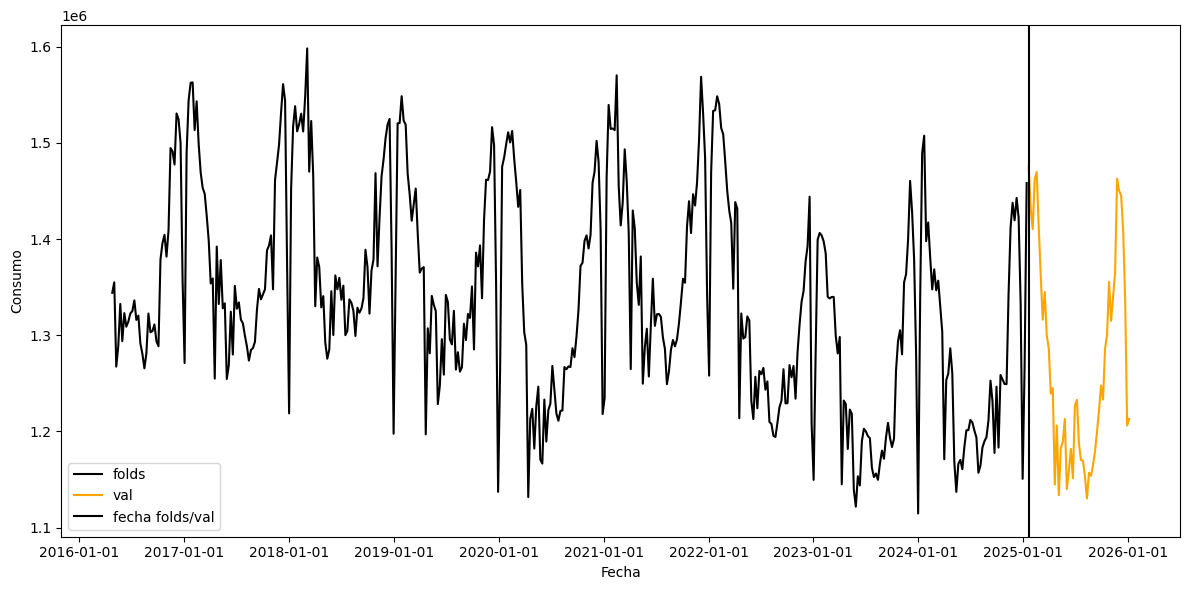

In [15]:
percentage = 0.9
folds_data_size = int(len(df_data_close_copy) * percentage)
folds_data = df_data_close_copy[:folds_data_size]
val_data = df_data_close_copy[folds_data_size:]
start_val_data = val_data["Start date"].values[0]
len(val_data)

# gráfica división folds/val
plt.figure(figsize=(12,6))
plt.plot(folds_data["Start date"], folds_data["value"], label="folds", color="black")
plt.plot(val_data["Start date"], val_data["value"], label="val", color="orange")
plt.axvline(start_val_data, color="black", label="fecha folds/val")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
#plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

In [16]:
# longitud del conjunto de datos trainG y testf
print(len(folds_data))
print(len(val_data))

456
51


Visualización de los folds a implementar

In [17]:
# visualizacion de los folds 
# se muestra de forma visual como funcionan los folds
# si no se define el tamaño de test, en la primera iteracion se toma igual cantidad de datos para train que para test
# por eso se toman los folds de prueba como de la longitud de datos de validación

gap = 8 # distancia (cantidad de observaciones) que se deja entre train y test
tscv = TimeSeriesSplit(
    n_splits=5
    #test_size=size_test, 
    #gap=gap
)

folds, indexes, types = [], [], []

for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(folds_data)):
    folds.extend([fold_idx] * len(train_idx)) 
    indexes.extend(train_idx)
    types.extend(['Train'] * len(train_idx))

    folds.extend([fold_idx] * len(test_idx))
    indexes.extend(test_idx)
    types.extend(['Test'] * len(test_idx))

# figura con plotly
fig = go.Figure()

# data train
fig.add_trace(go.Scatter(
    x=indexes, y=folds,
    mode='markers',
    marker=dict(color=['blue' if t == 'Train' else 'orange' for t in types], size=6),
    text=types,
    hovertemplate='Index: %{x}<br> Fold: %{y}<br> Tipo: %{text}<extra></extra>'
))

fig.update_layout(
    title='Folds',
    xaxis_title='Indices serie',
    yaxis_title='Fold',
    yaxis=dict(autorange='reversed'),
    legend_title='Tipo de conjunto',
    template='plotly_white',
    height=400
)
fig.show()

# Función de optimización

Mediante el uso de Optuna (una librería basada en técnicas de optimización bayesiana secuencial) se define una función de optimización que utiliza validación cruzada temporal para minimizar una métrica de error (en este caso, el MAPE*).

La función está dada de la siguiente forma: primero, se definen los hiperparámetros de la rnn: número de rezagos, unidades recurrentes, tasa de aprendizaje, tamaño de lote y número de épocas.   Para cada uno de estos parámetros se especifican rangos o conjuntos discretos de valores que Optuna explorará con el fin de encontrar la combinación que minimice el error promedio.

Posteriormente, se inicializan listas que almacenarán las métricas de evaluación obtenidas en cada fold (MAPE, MAE y RMSE).  
Durante cada iteración del proceso de validación cruzada, se realiza lo siguiente:
0. se definen los conjuntos train/test de acuerdo con ese fold
1. Se instancia un nuevo modelo RNN con el conjunto de hiperparámetros seleccionados para el trial actual.  
2. Se entrena el modelo sobre el conjunto de entrenamiento definido para ese fold.  
3. Se evalúa el modelo sobre el conjunto de prueba correspondiente, calculando las métricas de error.  

Este proceso se repite para los *k* folds (en este caso, 5), produciendo un conjunto de errores por fold:

- Fold₁ → MAPE₁  
- Fold₂ → MAPE₂  
- Fold₃ → MAPE₃  
- Fold₄ → MAPE₄  
- Fold₅ → MAPE₅  

Así se obtiene el MAPE promedio de los cinco folds:$$ \text{MAPE}_{prom} = \frac{1}{5} \sum_{i=1}^{5} \text{MAPE}_i $$

Este valor se devuelve como resultado de la función objetivo, y representa el desempeño promedio del modelo bajo ese conjunto de hiperparámetros. Optuna repite este proceso en múltiples trials, cada uno con una combinación diferente de hiperparámetros, y selecciona el conjunto que minimiza el MAPE promedio obtenido.


In [18]:
# función objetivo
def objective(trial):
    # parametros de la red
    #input_timesteps = trial.suggest_categorical('input_timesteps', [1,2,7,15,30,60,90]) # ventana temporal /rezagos
    #input_timesteps = trial.suggest_categorical('input_timesteps', [1,2,4,8,12,26,52]) # ventana temporal /rezagos (ventanas históricas de datos)
    input_timesteps = trial.suggest_categorical('input_timesteps', [1]) # ventana temporal /rezagos
    units = trial.suggest_int("units", 32, 256, step=32)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch = trial.suggest_categorical('batch_size', [16,35,64,128])
    epochs = trial.suggest_int('epochs', 40, 120)
    dropout = trial.suggest_float('dropout_rate', 0.0, 0.3)
    recurrent_dropout = trial.suggest_float('recurrent_dropput_rate', 0.0, 0.3)

    # redimensionado de folds_data
    
    # ---- Datos base ----
    data_raw = folds_data[features].values.astype(np.float32)
    target_raw = folds_data[target].values.astype(np.float32).ravel()

    # ---- Construcción de ventanas ----
    X_fold, y_fold = create_dataset(
        data_raw,
        target_raw,
        input_timesteps
    )

    # se almacenan las metricas por fold
    mapes, maes, rmses, smapes = [], [], [], []

    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_fold)):

        # reproductibilidad en cada fold
        tf.random.set_seed(42)
        np.random.seed(42)

        # escalado por fold
        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()

        # datos de entrenamiento por fold
        X_train_raw = X_fold[train_idx]
        y_train_raw = y_fold[train_idx].reshape(-1,1)

        # fold de test
        X_test_raw = X_fold[test_idx]
        y_test_raw = y_fold[test_idx].reshape(-1,1)

        # REescalado
        X_train = scaler_X.fit_transform(
            X_train_raw.reshape(-1, X_fold.shape[2])
        ).reshape(X_train_raw.shape)


        X_test = scaler_X.transform(
            X_test_raw.reshape(-1, X_fold.shape[2])
        ).reshape(X_test_raw.shape)

        y_train = scaler_y.fit_transform(y_train_raw)
        y_test = scaler_y.transform(y_test_raw)

        n_features = X_train.shape[-1]

        # se onstruye el modelo
        model = build_rnn(
            input_timesteps,
            n_features,
            units,
            lr,
            dropout,
            recurrent_dropout
        )

        # se fija el modelo
        model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch,
            shuffle=False,
            verbose=0
        )

        # predicción sobre el fold de prueba
        y_pred_scaled = model.predict(X_test, verbose=0)

        y_pred = scaler_y.inverse_transform(y_pred_scaled)
        y_true = y_test_raw

        # Métricas de error 
        mae = mean_absolute_error(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        smape_calc = MeanAbsolutePercentageError(symmetric=True)
        smape = smape_calc(y_true, y_pred)

        # se añaden a los arrays
        mapes.append(mape)
        maes.append(mae)
        rmses.append(rmse)
        smapes.append(smape)

        # se guarda registro del trial como atributo de usuario del study para poder consultarlo luego
        trial.set_user_attr(f"fold_{fold_idx + 1}", {"mae": mae, "mape": mape, "rmse": rmse, "smape": smape})
        # se reporta el valor de la media de los mapes
        trial.report(np.mean(mapes), step=fold_idx)

    
    # Función objetivo
    mean_mape = np.mean(mapes)
    mean_smape = np.mean(smapes)
    mean_rmse = np.mean(rmses)
    mean_mae = np.mean(maes)

    trial.set_user_attr("mape_mean", mean_mape)
    trial.set_user_attr("mae_mean", mean_mae)
    trial.set_user_attr("rmse_mean", mean_rmse)
    trial.set_user_attr("smape_mean", mean_smape)
    
    
    return float(mean_mape) #+ 0.25 * std_mape)
    
# se ejecuta la optimización con Optuna
print("Optimización con Optuna")
# se crea el caso de estudio, con el objetivo y la función a minimizar
study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=50)


[I 2026-04-02 20:58:26,287] A new study created in memory with name: no-name-7c6a559e-5a05-4811-8c31-0f4a369ee4c1


Optimización con Optuna


[I 2026-04-02 20:58:54,970] Trial 0 finished with value: 0.046751507371664044 and parameters: {'input_timesteps': 1, 'units': 96, 'lr': 0.007969454818643935, 'batch_size': 16, 'epochs': 44, 'dropout_rate': 0.2598528437324805, 'recurrent_dropput_rate': 0.18033450352296262}. Best is trial 0 with value: 0.046751507371664044.
[I 2026-04-02 20:59:24,808] Trial 1 finished with value: 0.04531711414456367 and parameters: {'input_timesteps': 1, 'units': 192, 'lr': 0.00010994335574766199, 'batch_size': 16, 'epochs': 54, 'dropout_rate': 0.09127267288786131, 'recurrent_dropput_rate': 0.15742692948967135}. Best is trial 1 with value: 0.04531711414456367.
[I 2026-04-02 21:00:06,645] Trial 2 finished with value: 0.04595291092991829 and parameters: {'input_timesteps': 1, 'units': 128, 'lr': 0.0003823475224675188, 'batch_size': 16, 'epochs': 76, 'dropout_rate': 0.23555278841790406, 'recurrent_dropput_rate': 0.05990213464750792}. Best is trial 1 with value: 0.04531711414456367.
[I 2026-04-02 21:00:52,03

en cada trial se devuelven datos relacionados con
- valor mape mínimo
- conjunto de hiperparámetros
- trial que ha dejado menor mape (o métrica seleccionada) hasta el momento
- errores promedio por fold (mape, mae, rmse, smape)

In [19]:
# mejor conjunto de hiperparámetros
study.best_params

{'input_timesteps': 1,
 'units': 64,
 'lr': 0.007863831324361003,
 'batch_size': 35,
 'epochs': 90,
 'dropout_rate': 0.19982380565626268,
 'recurrent_dropput_rate': 0.1349116667171795}

información de los trials

In [20]:
# info de los trials 
# se extraen los trials
trials = study.get_trials()
for trial in trials:
    trial_number = trial.number # número de trial: trial 1, 2,...
    attrs = trial.user_attrs
    print(attrs)

{'fold_1': {'mae': 58932.71875, 'mape': 0.04275578632950783, 'rmse': 78713.42411558527, 'smape': 0.041598763316869736}, 'fold_2': {'mae': 59252.02734375, 'mape': 0.04670025780797005, 'rmse': 83499.6266338958, 'smape': 0.04474730044603348}, 'fold_3': {'mae': 64244.359375, 'mape': 0.04521287605166435, 'rmse': 81886.60569348323, 'smape': 0.045825764536857605}, 'fold_4': {'mae': 66099.6015625, 'mape': 0.053455885499715805, 'rmse': 82797.38894433809, 'smape': 0.05132896080613136}, 'fold_5': {'mae': 59392.78125, 'mape': 0.045632731169462204, 'rmse': 80295.47354614704, 'smape': 0.04633503407239914}, 'mape_mean': 0.046751507371664044, 'mae_mean': 61584.29765625, 'rmse_mean': 81438.5037866899, 'smape_mean': 0.04596716463565827}
{'fold_1': {'mae': 62525.234375, 'mape': 0.04454222321510315, 'rmse': 81622.29969806045, 'smape': 0.044089414179325104}, 'fold_2': {'mae': 61205.62109375, 'mape': 0.048268623650074005, 'rmse': 81215.8991331131, 'smape': 0.04647388309240341}, 'fold_3': {'mae': 59729.93359

creacion df errores por fold y por trial

In [46]:
# creación del df a nivel de registro
# el esquema del df se infiere a partir de las claves almacenadas 
# en cada registro (las claves no varían)
rows = [] # se usará para guardar la info a nivel de registro
for trial in trials:
    trial_number = trial.number # número de trial: trial 1, 2,...
    attrs = trial.user_attrs # los valores de las métricas se definen en la función como 
    # un atributo de usuario, definido como un diccionario
    # se recorren ahora las claves y los valores de cada diccionario
    for key, value in attrs.items():
        if key.startswith("fold_") and isinstance(value, dict): 
            # se examina si cada clave del diccionario empieza con fold_. Recordar que en la función
            # se guardó un diccionario con el nombre fold_i_metrics, que guarda la info de cada fold y cada trial.
            # Se mira entonces si la clave es de esa forma y si el valor de esa clave es un diccionario
            rows.append({
                "trial": trial_number,
                "fold": key[-1],
                "mape": value.get("mape"),
                "mae": value.get("mae"),
                "rmse": value.get("rmse"),
                "smape": value.get("smape")
            }) 
df_metrics = pd.DataFrame(rows)
df_metrics = df_metrics.sort_values(by="mape")
df_metrics.head()

,trial,fold,mape,mae,rmse,smape
75,15,1,0.03,43563.10,60668.70,0.03
80,16,1,0.03,45455.27,65306.37,0.03
70,14,1,0.04,49115.76,67189.33,0.03
30,6,1,0.04,49536.01,66582.65,0.04
165,33,1,0.04,49776.17,66656.09,0.04


In [47]:
# descripción general del df de métricas
df_stats = df_metrics.describe()
df_stats[["mape", "mae", "rmse", "smape"]]

,mape,mae,rmse,smape
count,250.00,250.00,250.00,250.00
mean,0.05,59678.13,78012.22,0.04
std,0.01,7609.93,7011.07,0.01
min,0.03,43563.10,60668.70,0.03
25%,0.04,54307.63,73563.19,0.04
50%,0.04,57483.68,76724.26,0.04
75%,0.05,63095.74,81721.27,0.05
max,0.07,83667.85,101370.58,0.06


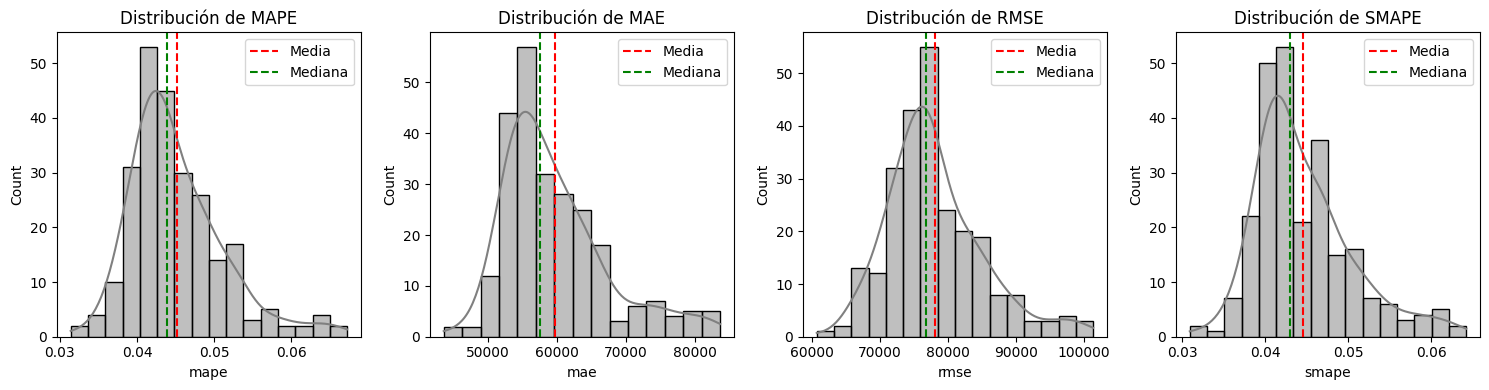

In [48]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, metric in zip(axes, ["mape", "mae", "rmse", "smape"]):
    sns.histplot(df_metrics[metric], kde=True, ax=ax, color="gray")
    ax.set_title(f"Distribución de {metric.upper()}")
    ax.axvline(df_metrics[metric].mean(), color='red', linestyle='--', label='Media')
    ax.axvline(df_metrics[metric].median(), color='green', linestyle='--', label='Mediana')
    ax.legend()

plt.tight_layout()
plt.show()


In [49]:
summary = df_metrics.groupby("trial")[["mape", "mae", "rmse", "smape"]].agg(["mean", "std"])
summary.columns = ["_".join(col) for col in summary.columns]
summary = summary.sort_values("mape_mean")
summary.head()


,mape_mean,mape_std,mae_mean,mae_std,rmse_mean,rmse_std,smape_mean,smape_std
trial,,,,,,,,
44,0.04,0.00,53243.40,1690.58,70989.20,3193.57,0.04,0.00
48,0.04,0.00,54279.84,2207.16,72774.26,4810.26,0.04,0.00
23,0.04,0.00,54721.39,3699.36,71674.28,1440.59,0.04,0.00
31,0.04,0.00,54903.64,1610.04,74003.61,2929.39,0.04,0.00
22,0.04,0.00,54948.94,2803.64,72682.67,2581.54,0.04,0.00


revisar referencias 
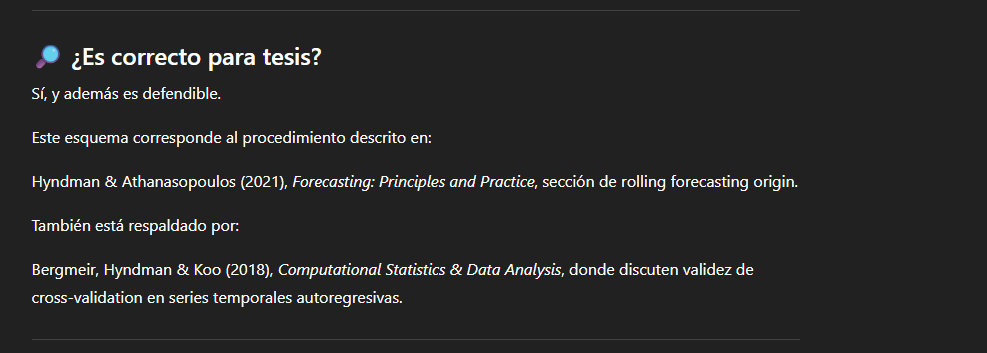

In [25]:
# validación

best_params = study.best_params

In [26]:
best_params

{'input_timesteps': 1,
 'units': 64,
 'lr': 0.007863831324361003,
 'batch_size': 35,
 'epochs': 90,
 'dropout_rate': 0.19982380565626268,
 'recurrent_dropput_rate': 0.1349116667171795}

Se crea df que obtiene los hiperparametros por fold junto con las metricas asociadas, se toman los 3 que dejan menor mape promedio para comparar y luego se toma uno solo

In [43]:
df_trials = {
    "trial": [],
    "input_timesteps": [],
    "units": [],
    "lr": [],
    "epochs": [],
    "dropout_rate": [],
    "mape_mean": [],
    "mae_mean": [],
    "rmse_mean": [],
    "smape_mean": []
}

for trial in trials:
    for key in df_trials:

        if key == "trial":
            df_trials[key].append(trial.number)

        elif key in ["mape_mean", "smape_mean"]:
            value = trial.user_attrs.get(key, None)
            df_trials[key].append(
                float(f"{value * 100:.6f}") if value is not None else None
            )

        elif key in ["mae_mean", "rmse_mean"]:
            value = trial.user_attrs.get(key, None)
            df_trials[key].append(value)

        else:
            df_trials[key].append(trial.params.get(key, None))

trials_df = pd.DataFrame(df_trials).sort_values(by="mape_mean")
trials_df.head()

,trial,input_timesteps,units,lr,epochs,dropout_rate,mape_mean,mae_mean,rmse_mean,smape_mean
44,44,1,64,0.01,90,0.20,4.03,53243.40,70989.20,3.97
48,48,1,32,0.00,107,0.10,4.11,54279.84,72774.26,4.06
23,23,1,64,0.01,108,0.21,4.11,54721.39,71674.28,4.08
31,31,1,96,0.01,96,0.13,4.15,54903.64,74003.61,4.09
22,22,1,64,0.01,97,0.18,4.16,54948.94,72682.67,4.10


In [44]:
# se exporta el df anterior
# 
trials_df.head(3).to_csv("../../../data/best_train_models/best_models_rnn.csv")

Se realiza ahora la predicción sobre los datos de validación con el mejor conjunto de hiperparametros encontrado

In [29]:
# ventanas temporales optimas
L = best_params["input_timesteps"]

# datos de forma supervisada train
X_train, y_train = create_dataset(
    folds_data[features].values,
    folds_data[target].values.ravel(),
    L
) 

# test - se anexan los ultimos L registros de train para continuidad

combined = pd.concat(
    [folds_data.tail(L), val_data],
    axis=0
).reset_index(drop=True)

X_test_all, y_test_all = create_dataset(
    combined[features].values,
    combined[target].values.ravel(),
    L
)

X_val = X_test_all
y_val = y_test_all

print(f"len val_data: {len(val_data)}") 
print(f"len y_test: {len(y_test_all)}") 


len val_data: 51
len y_test: 51


In [30]:
# ventanas temporales optimas
L = best_params["input_timesteps"]

# escalado 
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# se reescalan las features y el target (recordar que la RNN recibe todos los valores en [0,1])
n_features = X_train.shape[-1] # devuelve la longitud del array de mas adentro (la cantidad de variables-longitud de features)

X_train_rescaled = scaler_X.fit_transform(
    X_train.reshape(-1, n_features) #redimensiona un tensor de orden 3 en una matriz - porque el fit_transform recibe es una matriz
).reshape(X_train.shape)

X_test_rescaled = scaler_X.transform(
    X_val.reshape(-1, n_features)
).reshape(X_val.shape)

y_train_rescaled = scaler_y.fit_transform(
    y_train.reshape(-1,1)
)

# se fija el modelo con los mejores hiperparametros encontrados
final_model = build_rnn(
    L,
    n_features,
    best_params["units"],
    best_params["lr"],
    dropout_rate=best_params["dropout_rate"],
    recurrent_dropout_rate=best_params["recurrent_dropput_rate"]
)

#early stop
early_stop = callbacks.EarlyStopping(
    monitor="loss",
    patience=10,
    restore_best_weights=True
)

# se fija el modelo a los datos de folds
final_model.fit(
    X_train_rescaled,
    y_train_rescaled,
    epochs=best_params["epochs"],
    batch_size=best_params["batch_size"],
    shuffle=False,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/90
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1063
Epoch 2/90
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0418 
Epoch 3/90
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0339 
Epoch 4/90
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0343 
Epoch 5/90
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0302 
Epoch 6/90
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0323 
Epoch 7/90
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0310 
Epoch 8/90
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0283 
Epoch 9/90
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0284 
Epoch 10/90
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0288 
Epoch 11/90
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0279 
Epoch 12/90
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0341  
Epoch 13/90
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0292 
Epoch 14/90
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0310 
Epoch 15/90
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0257 
Epoc

Se obtienen las predicciones y se calculan las métricas de error respecto a los datos de validación

In [31]:
y_true = val_data["value"].values
y_pred_scaled = final_model.predict(X_test_rescaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# métricas de error
smape_fn = MeanAbsolutePercentageError(symmetric=True)
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = mean_absolute_percentage_error(y_true, y_pred)
smape = smape_fn(y_true, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape*100:.4f}%")
print(f"sMAPE: {smape*100:.4f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
MAE: 56858.880774976664
RMSE: 69114.2843784739
MAPE: 4.3802%
sMAPE: 4.4407%


In [32]:
y_pred_scaled

array([[0.43183205 ],
       [0.5508537  ],
       [0.5546139  ],
       [0.53147256 ],
       [0.51929426 ],
       [0.5395275  ],
       [0.58200437 ],
       [0.529455   ],
       [0.48922116 ],
       [0.46066263 ],
       [0.46274528 ],
       [0.39624396 ],
       [0.34589323 ],
       [0.31678316 ],
       [0.30172196 ],
       [0.22883019 ],
       [0.16885738 ],
       [0.11568436 ],
       [0.09739704 ],
       [0.12476964 ],
       [0.1216326  ],
       [0.093541056],
       [0.07505895 ],
       [0.09558348 ],
       [0.06935669 ],
       [0.115804575],
       [0.16996478 ],
       [0.13525315 ],
       [0.117045514],
       [0.0976016  ],
       [0.0758429  ],
       [0.04172628 ],
       [0.05998433 ],
       [0.05984242 ],
       [0.069437474],
       [0.08834946 ],
       [0.08351539 ],
       [0.13751528 ],
       [0.16492788 ],
       [0.20544079 ],
       [0.24440445 ],
       [0.28179547 ],
       [0.32326564 ],
       [0.3593181  ],
       [0.3904222  ],
       [0.

Se grafican los datos

In [33]:
len(y_true)

51

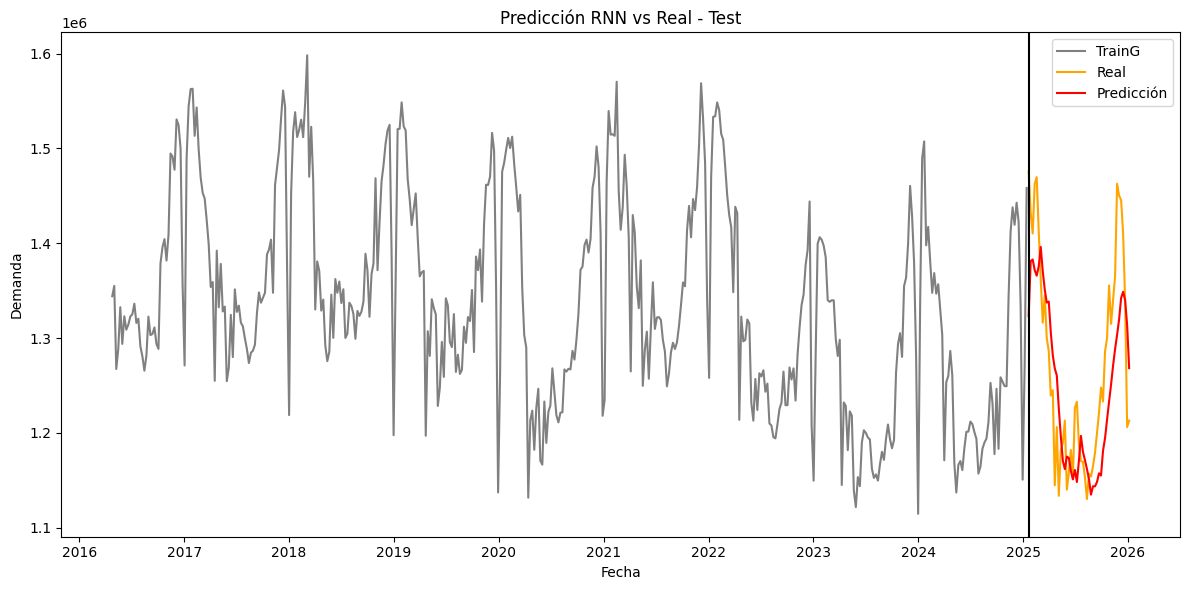

In [52]:
# Fechas reales del test

plt.figure(figsize=(12,6))
plt.plot(folds_data["Start date"], folds_data["value"], label="TrainG", color="gray")
plt.plot(val_data["Start date"], y_true, label="Real", color="orange")
plt.plot(val_data["Start date"], y_pred, label="Predicción", color='red')
#plt.plot(folds_data["Start date"], folds_data["value"].values, label="train", color='gray')
plt.axvline(start_val_data, color="black")
plt.title("Predicción RNN vs Real - Test")
plt.xlabel("Fecha")
plt.ylabel("Demanda")
plt.legend()
plt.tight_layout()
plt.show()

Se exportan las predicciones en json para poder calcular luego la predicción conjunta


In [35]:
arr_preds = []
for index, value in enumerate(val_data["Start date"].values):
    dict_pred = {
        "Date": np.datetime_as_string(value, unit="D"), # convierte a la fecha a string para poder exportar a json
        "pred" : float(y_pred[index][0])
    }
    arr_preds.append(dict_pred)
arr_preds

[{'Date': '2025-01-20', 'pred': 1323487.5},
 {'Date': '2025-01-27', 'pred': 1381029.375},
 {'Date': '2025-02-03', 'pred': 1382847.125},
 {'Date': '2025-02-10', 'pred': 1371659.375},
 {'Date': '2025-02-17', 'pred': 1365771.75},
 {'Date': '2025-02-24', 'pred': 1375553.625},
 {'Date': '2025-03-03', 'pred': 1396089.25},
 {'Date': '2025-03-10', 'pred': 1370684.0},
 {'Date': '2025-03-17', 'pred': 1351232.75},
 {'Date': '2025-03-24', 'pred': 1337426.0},
 {'Date': '2025-03-31', 'pred': 1338432.75},
 {'Date': '2025-04-07', 'pred': 1306282.375},
 {'Date': '2025-04-14', 'pred': 1281940.0},
 {'Date': '2025-04-21', 'pred': 1267866.5},
 {'Date': '2025-04-28', 'pred': 1260585.125},
 {'Date': '2025-05-05', 'pred': 1225345.25},
 {'Date': '2025-05-12', 'pred': 1196351.125},
 {'Date': '2025-05-19', 'pred': 1170644.25},
 {'Date': '2025-05-26', 'pred': 1161803.125},
 {'Date': '2025-06-02', 'pred': 1175036.5},
 {'Date': '2025-06-09', 'pred': 1173520.0},
 {'Date': '2025-06-16', 'pred': 1159939.0},
 {'Date': 

In [36]:
# Cálculo de métricas agregadas
dict_to_export = {
    "mape_val": float(mape),
    "mae_val": float(mae),
    "smape_val": float(smape),
    "rmse_val": float(rmse),
    "predictions": arr_preds
}
#with open ("../../../data/preds_energy_models/rnn_preds.json", "w") as json_file:
#    json.dump(dict_to_export, json_file, indent=4)